In [7]:
pip install sentence-transformers numpy


In [8]:
import numpy as np
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    "저는 경기대학교 학생입니다",
    "경기대학교는 수원시에 위치하고 있습니다.",
    "사과가 맛있습니다."
]
vectors = model.encode(sentences)
v1, v2, v3 = vectors[0], vectors[1], vectors[2]


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
def get_similarity(a,b) :
  dot_product = np.dot(a,b)
  norm_a = np.linalg.norm(a)
  norm_b = np.linalg.norm(b)
  return dot_product / (norm_a * norm_b)
#

차원 수: 384차원
------------------------------
비슷한 문장 유사도: 0.7699
다른 문장 유사도: 0.5324


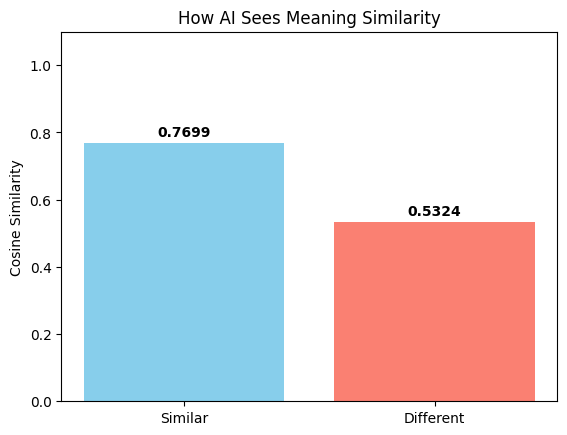

In [18]:
import matplotlib.pyplot as plt
print(f"차원 수: {v1.shape[0]}차원") # 이 모델은 문장을 384개의 숫자로 바꿉니다.
print("-" * 30)
print(f"비슷한 문장 유사도: {get_similarity(v1, v2):.4f}")
print(f"다른 문장 유사도: {get_similarity(v1, v3):.4f}")
import matplotlib.pyplot as plt


labels = ["Similar", "Different"]
values = [get_similarity(v1, v2), get_similarity(v1, v3)]


plt.bar(labels, values, color=['skyblue', 'salmon'])


plt.ylabel('Cosine Similarity')
plt.title('How AI Sees Meaning Similarity')
plt.ylim(0, 1.1)


for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()